# 포트폴리오 백테스팅

**실행 순서**: 셀을 위에서 아래로 순서대로 실행

| 단계 | 내용 |
|------|------|
| 1 | 전략 선택 (`neutral` / `aggressive`) |
| 2 | 종목 리스트 정의 |
| 3 | 백테스팅 기간 정의 + 데이터 다운로드 |
| 4 | Walk-Forward 백테스팅 실행 |
| 5 | 결과 분석 및 시각화 |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import koreanize_matplotlib

from stock_system.profiles import get_profile
from stock_system.backtest.portfolio import run_walk_forward, run_bh_portfolio
from stock_system.backtest.metrics import build_metrics_table, build_period_stats_table
from stock_system.backtest.plots.performance import (
    plot_equity_curves,
    plot_weight_heatmap,
    plot_contribution,
    plot_diversification,
    plot_yearly_returns,
    plot_mdd_comparison,
    plot_yearly_stock_etf,
    plot_quarterly_returns,
    plot_monthly_heatmap,
)
from stock_system.backtest.plots.optimizer import plot_walkforward_portfolio_comparison
from stock_system.backtest.plots.strategy import plot_regime
from stock_system.strategies.partial import make_signals

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 전략 선택

| 전략 | 특징 |
|------|------|
| `neutral` | 위험중립형 — ADX 25, 진입 40%→70%, WF 12+3개월 |
| `aggressive` | 적극투자형 — ADX 20, 진입 60%→90%, WF 12+3개월 |

In [2]:
# ── 전략 선택: 'neutral' 또는 'aggressive' ────────────────────
PROFILE_NAME = 'neutral'

profile = get_profile(PROFILE_NAME)

print(f'선택된 전략 : {PROFILE_NAME}')
print(f'  ADX 임계값    : {profile.ADX_THRESHOLD}')
print(f'  ADX 횡보 기준 : {profile.ADX_SIDEWAYS}')
print(f'  1차 진입 비중 : {profile.ENTRY1_SIZE:.0%}')
print(f'  2차 진입 비중 : {profile.ENTRY2_SIZE:.0%}')
print(f'  횡보 진입 비중: {profile.ENTRY_RANGE_SIZE:.0%}')
print(f'  ATR 승수      : {profile.ATR_MULTIPLIER}')
print(f'  수수료        : {profile.FEES:.2%}')
print(f'  슬리피지      : {profile.SLIPPAGE:.2%}')
print(f'  WF 학습 기간  : {profile.WF_TRAIN_MONTHS}개월')
print(f'  WF 검증 기간  : {profile.WF_TEST_MONTHS}개월')

선택된 전략 : neutral
  ADX 임계값    : 25.0
  ADX 횡보 기준 : 20.0
  1차 진입 비중 : 40%
  2차 진입 비중 : 70%
  횡보 진입 비중: 30%
  ATR 승수      : 2.0
  수수료        : 0.15%
  슬리피지      : 0.10%
  WF 학습 기간  : 12개월
  WF 검증 기간  : 3개월


---
## 2. 종목 리스트 정의

`STOCKS` 딕셔너리에서 종목명(한글)과 야후파이낸스 티커를 수정하세요.  
`CASH_ETF_TICKER`를 `None`으로 바꾸면 현금 ETF 없이 실행됩니다.

In [3]:
# ── 백테스팅 종목 (종목명: 야후파이낸스 티커) ──────────────────
STOCKS = {
    '삼성전자'  : '005930.KS',
    'SK하이닉스' : '000660.KS',
    'NAVER'     : '035420.KS',
    '카카오'    : '035720.KS',
    '삼성SDI'   : '006400.KS',   # LG에너지솔루션(2022 상장) → 삼성SDI(2000 상장)
}

KOSPI_TICKER    = '^KS11'       # KOSPI 벤치마크
CASH_ETF_TICKER = '153130.KS'   # KODEX 단기채권 — None 으로 바꾸면 비활성
CASH_ETF_NAME   = '단기채'

names   = list(STOCKS.keys())
tickers = list(STOCKS.values())

print(f'백테스팅 종목 ({len(STOCKS)}개):')
for name, ticker in STOCKS.items():
    print(f'  {name:16s}: {ticker}')
print(f'\nKOSPI   : {KOSPI_TICKER}')
print(f'현금 ETF : {CASH_ETF_TICKER}')

백테스팅 종목 (5개):
  삼성전자            : 005930.KS
  SK하이닉스          : 000660.KS
  NAVER           : 035420.KS
  카카오             : 035720.KS
  삼성SDI           : 006400.KS

KOSPI   : ^KS11
현금 ETF : 153130.KS


---
## 3. 백테스팅 기간 정의 + 데이터 다운로드

In [4]:
# ── 기간 설정 ─────────────────────────────────────────────────
START_DATE = '2019-01-01'
END_DATE   = '2024-12-31'

print(f'백테스팅 기간: {START_DATE} ~ {END_DATE}')

백테스팅 기간: 2019-01-01 ~ 2024-12-31


In [5]:
# ── 야후파이낸스 데이터 다운로드 ──────────────────────────────
dl_tickers = tickers + [KOSPI_TICKER]
if CASH_ETF_TICKER:
    dl_tickers.append(CASH_ETF_TICKER)

raw = yf.download(dl_tickers, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

def _get(field, cols):
    return raw[field][cols].ffill()

close_df  = _get('Close',  tickers).rename(columns=dict(zip(tickers, names)))
high_df   = _get('High',   tickers).rename(columns=dict(zip(tickers, names)))
low_df    = _get('Low',    tickers).rename(columns=dict(zip(tickers, names)))
volume_df = _get('Volume', tickers).rename(columns=dict(zip(tickers, names)))

# 전 종목 데이터가 없는 날 제거
valid = close_df.notna().all(axis=1)
close_df, high_df, low_df, volume_df = (
    close_df[valid], high_df[valid], low_df[valid], volume_df[valid]
)

kospi    = _get('Close', [KOSPI_TICKER])[KOSPI_TICKER]
cash_etf = _get('Close', [CASH_ETF_TICKER])[CASH_ETF_TICKER] if CASH_ETF_TICKER else None

print(f'데이터 기간 : {close_df.index[0].date()} ~ {close_df.index[-1].date()}')
print(f'총 영업일수 : {len(close_df)}일')
print(f'종목 수     : {len(names)}개')
close_df.tail(3)

데이터 기간 : 2019-01-02 ~ 2024-12-30
총 영업일수 : 1475일
종목 수     : 5개


Ticker,삼성전자,SK하이닉스,NAVER,카카오,삼성SDI
Date,,,,,
2024-12-26,52005.328125,168028.6875,196856.390625,38438.015625,246022.875
2024-12-27,52457.621094,172375.1250,194689.875000,38737.140625,248000.000
2024-12-30,51969.183594,171782.4375,195871.609375,38089.031250,247500.000


---
## 4. 백테스팅 진행

### 4-1. 대표 종목 국면 미리보기

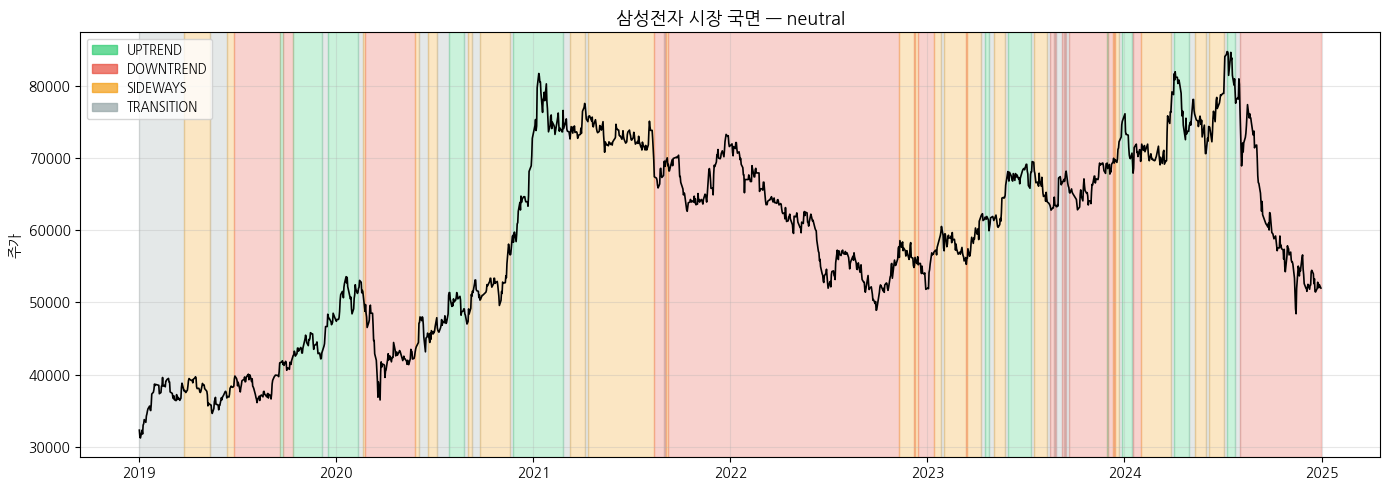


=== 국면 비율 ===
  UPTREND     :  234일  (15.9%)
  DOWNTREND   :  625일  (42.4%)
  SIDEWAYS    :  404일  (27.4%)
  TRANSITION  :  212일  (14.4%)


In [6]:
# ── 첫 번째 종목으로 4국면 시각화 미리보기 ───────────────────
sample = names[0]

_, _, _, detail = make_signals(
    close_df[sample], high_df[sample], low_df[sample],
    adx_threshold=profile.ADX_THRESHOLD,
    adx_sideways=profile.ADX_SIDEWAYS,
    kospi=kospi,
    kospi_ma=profile.KOSPI_MA,
    atr_multiplier=profile.ATR_MULTIPLIER,
    atr_period=profile.ATR_PERIOD,
)

plot_regime(close_df[sample], detail['regime'],
            title=f'{sample} 시장 국면 — {PROFILE_NAME}')

### 4-2. Walk-Forward 백테스팅

> **소요 시간 안내**  
> 종목 수 × WF 창 수 × 파라미터 조합 수에 비례합니다.  
> 5종목 / 5~6년 기준 약 **1~3분** 예상.

In [7]:
# ── Walk-Forward 백테스팅 + Buy & Hold 기준선 ─────────────────
print('Walk-Forward 백테스팅 실행 중 ...')

pf_wf, wf_info = run_walk_forward(
    profile,
    close_df, high_df, low_df, volume_df,
    kospi=kospi,
    cash_etf=cash_etf,
)

pf_bh = run_bh_portfolio(close_df, fees=profile.FEES, slippage=profile.SLIPPAGE)

print(f'완료 — {wf_info["n_windows"]}개 WF 구간')
print()
print(f'{"#":>3}  {"IS 기간":^23}  {"OOS 기간":^23}  {"adx_thr":>7}  {"adx_sw":>6}  {"IS score":>9}')
print('-' * 78)
for i, w in enumerate(wf_info['windows'], 1):
    p  = w['best_params']
    sc = w['best_score']
    print(
        f'  {i:2d}  '
        f'{str(w["train_start"].date())} ~ {str(w["train_end"].date())}  '
        f'{str(w["test_start"].date())} ~ {str(w["test_end"].date())}  '
        f'{p.get("adx_threshold"):>7}  '
        f'{p.get("adx_sideways"):>6}  '
        f'{"{:.3f}".format(sc) if not pd.isna(sc) else "N/A":>9}'
    )

Walk-Forward 백테스팅 실행 중 ...
완료 — 19개 WF 구간

  #           IS 기간                   OOS 기간           adx_thr  adx_sw   IS score
------------------------------------------------------------------------------
   1  2019-01-02 ~ 2020-01-02  2020-01-02 ~ 2020-04-01       15      10      2.222
   2  2019-04-02 ~ 2020-04-02  2020-04-02 ~ 2020-07-01       15      15      3.184
   3  2019-07-02 ~ 2020-07-02  2020-07-02 ~ 2020-09-29       20      15      1.241
   4  2019-10-02 ~ 2020-10-02  2020-10-05 ~ 2020-12-30       15      10      1.467
   5  2020-01-02 ~ 2021-01-02  2021-01-04 ~ 2021-04-01       30      10      2.946
   6  2020-04-02 ~ 2021-04-02  2021-04-02 ~ 2021-07-01       20      10      2.585
   7  2020-07-02 ~ 2021-07-02  2021-07-02 ~ 2021-10-01       20      10      4.428
   8  2020-10-02 ~ 2021-10-02  2021-10-05 ~ 2021-12-30       15      20      4.829
   9  2021-01-02 ~ 2022-01-02  2022-01-04 ~ 2022-04-01       20      10     -0.435
  10  2021-04-02 ~ 2022-04-02  2022-04-04 ~ 2022-

---
## 5. 결과 분석 및 시각화

### 5-1. 성과 지표 테이블

| 상태 | 의미 |
|------|------|
| ✓ | 목표 달성 |
| ⚠ | 경보선 이상, 목표 미달 |
| ✗ | 경보선 미달 |
| — | 해당 없음 |

In [8]:
tbl = build_metrics_table(pf_wf, pf_bh, close_df, profile, benchmark_series=kospi)
print(f'=== {PROFILE_NAME} 전략 성과 지표 ===\n')
tbl

=== neutral 전략 성과 지표 ===



,neutral 전략,B&H,목표,경보선,상태
지표,,,,,
CAGR,9.38%,11.22%,6.00%,4.00%,✓
MDD,-23.35%,-53.84%,-25.00%,-35.00%,✗
MDD기간(월),41.1,40.4,12.0,18.0,✗
Calmar,0.40,0.21,0.30,0.20,✓
Sortino,0.75,0.84,0.50,0.30,✓
Alpha,+7.58%,+8.43%,+2.00%,+0.00%,✓
Beta,0.30,1.10,0.80,1.00,✓
MDD감소율,-34.62%,50.77%,20.00%,10.00%,✗
Calmar개선,+0.35,+0.13,+0.10,+0.00,✓


### 5-2. 자산 곡선 · 드로다운 · 보유 종목 수

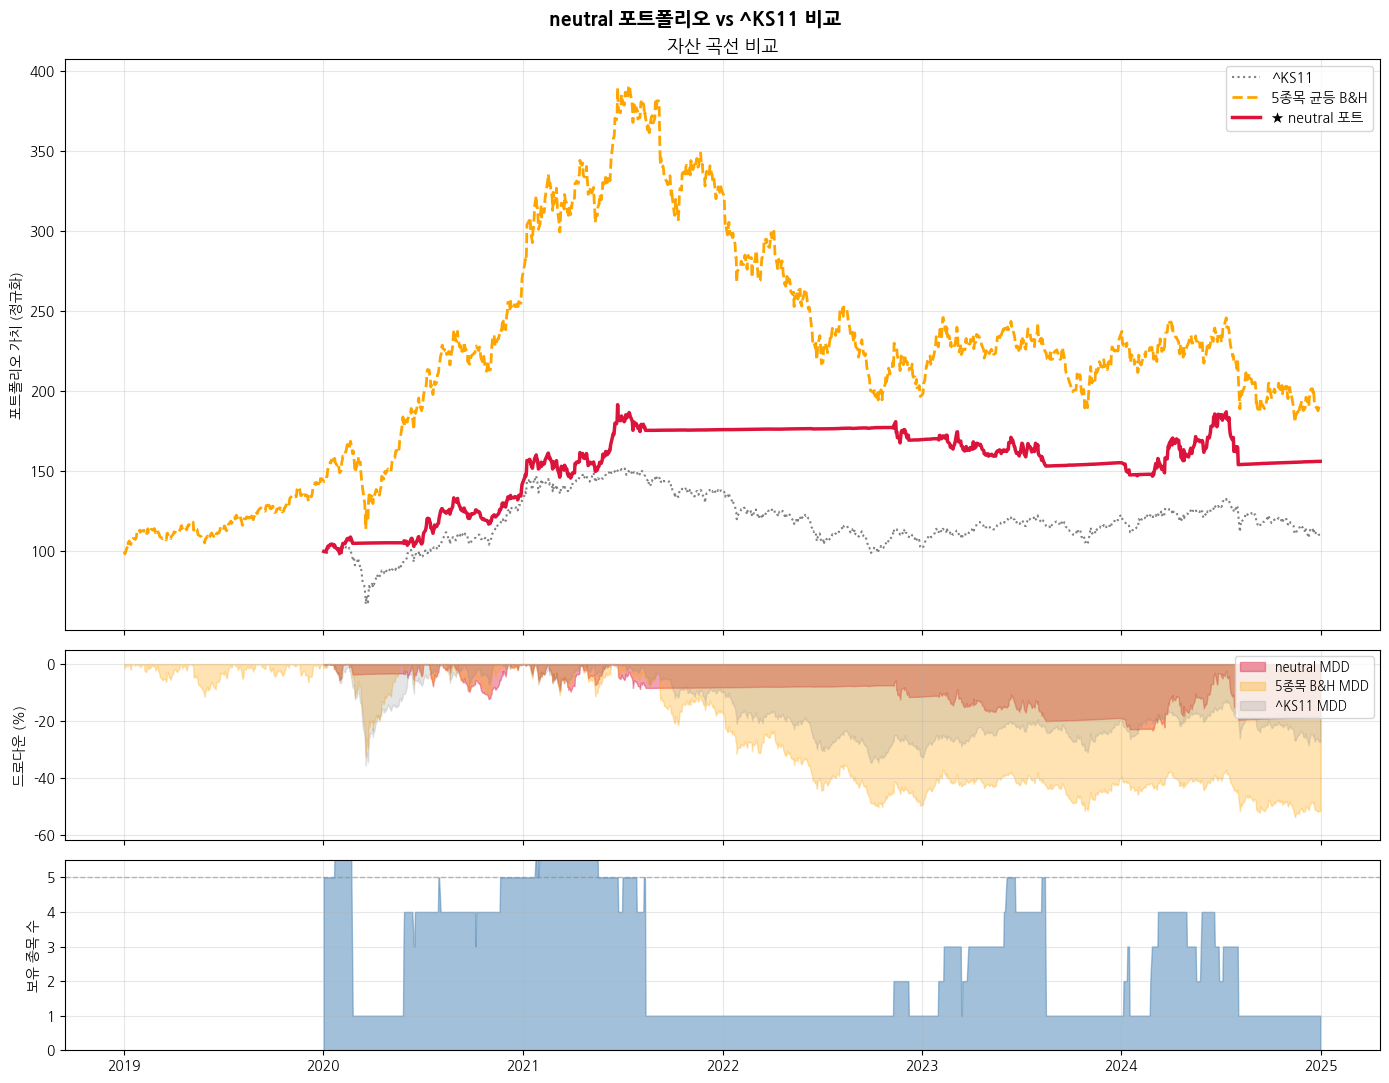

In [9]:
names_all = wf_info['names_all']

plot_equity_curves(
    pf_wf, pf_bh, names_all, len(names),
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### 5-3. Walk-Forward 구간별 파라미터 추이

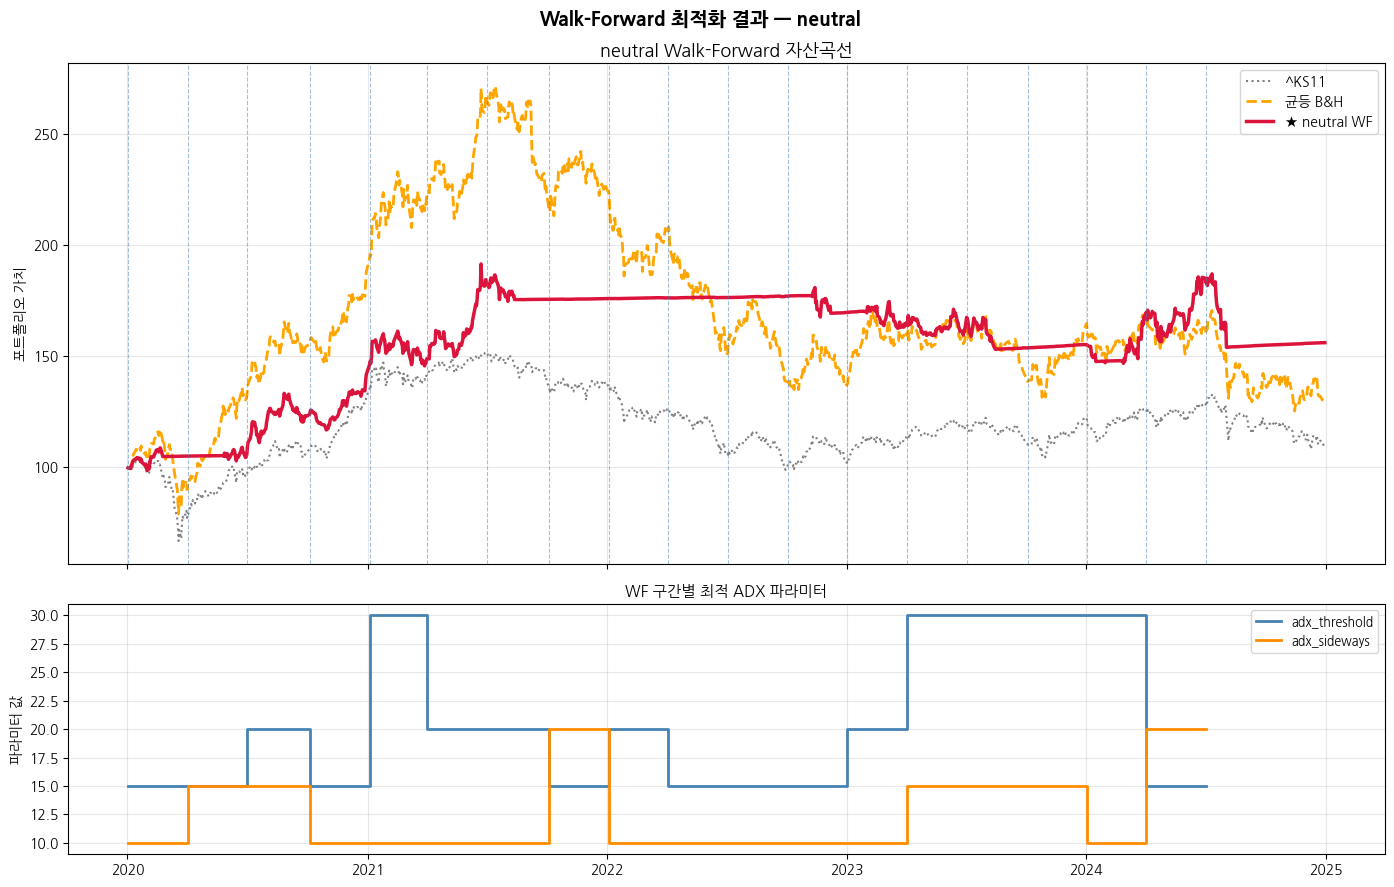


  구간         IS 시작        OOS 시작   adx_thr   adx_sw   IS score
--------------------------------------------------------------
   1    2019-01-02    2020-01-02        15       10      2.222
   2    2019-04-02    2020-04-02        15       15      3.184
   3    2019-07-02    2020-07-02        20       15      1.241
   4    2019-10-02    2020-10-05        15       10      1.467
   5    2020-01-02    2021-01-04        30       10      2.946
   6    2020-04-02    2021-04-02        20       10      2.585
   7    2020-07-02    2021-07-02        20       10      4.428
   8    2020-10-02    2021-10-05        15       20      4.829
   9    2021-01-02    2022-01-04        20       10     -0.435
  10    2021-04-02    2022-04-04        15       10     -0.437
  11    2021-07-02    2022-07-04        15       10        N/A
  12    2021-10-02    2022-10-04        15       10     -0.464
  13    2022-01-02    2023-01-02        20       10     -0.580
  14    2022-04-02    2023-04-03        30       15   

In [10]:
plot_walkforward_portfolio_comparison(
    pf_wf, pf_bh, wf_info,
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### 5-4. 연도별 성과 비교

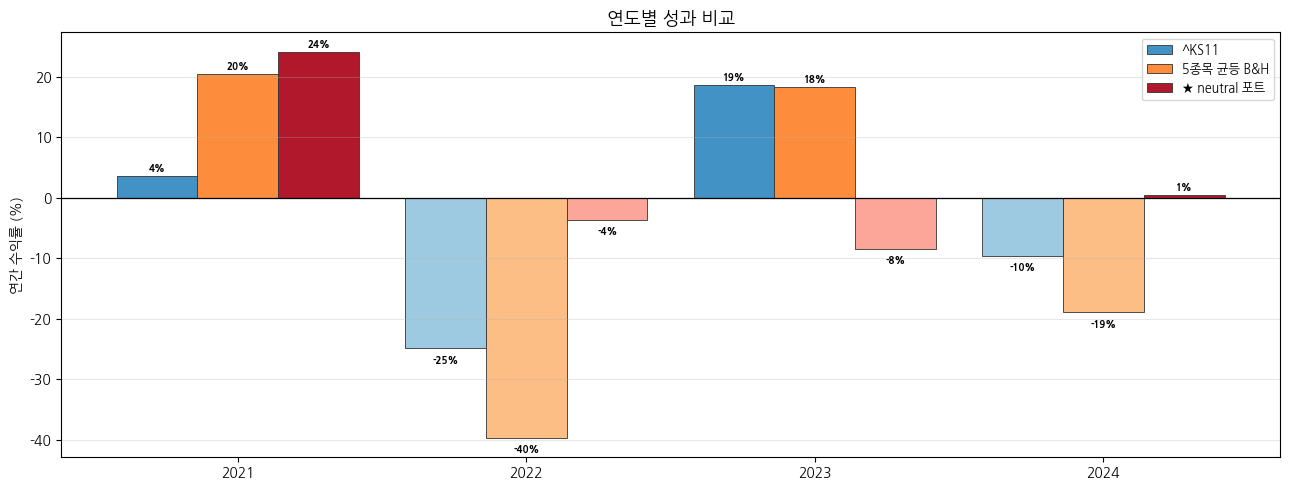

In [11]:
plot_yearly_returns(
    pf_wf, pf_bh, n=len(names),
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### 5-5. MDD Depth + Duration 비교

=== MDD 비교 ===
  KOSPI (벤치마크)        : MDD 35.7%  Duration 854일
  5종목 균등 B&H          : MDD 53.8%  Duration 848일
  neutral             : MDD 23.3%  Duration 863일

MDD depth: KOSPI -35.7% → neutral -23.3% (✅ 개선)


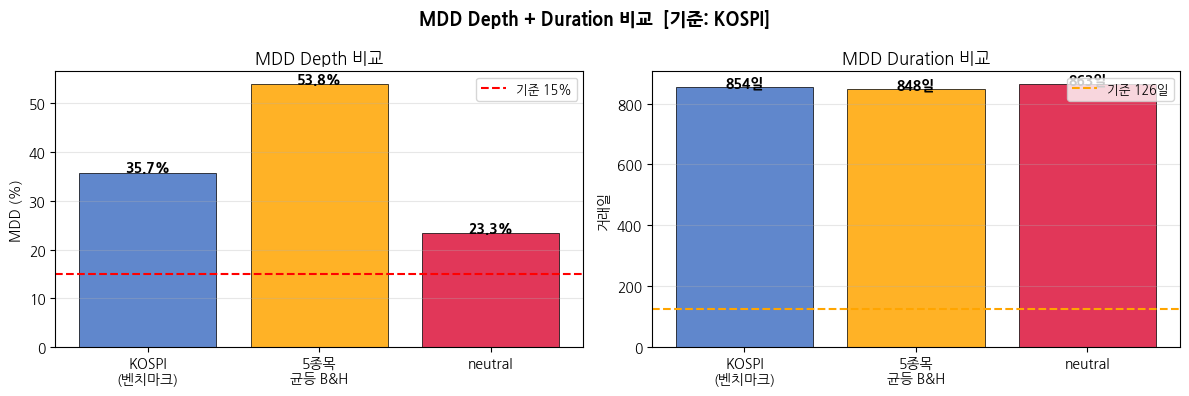

In [12]:
plot_mdd_comparison(
    pf_wf, pf_bh, kospi,
    n=len(names),
    profile_name=PROFILE_NAME,
)

### 5-6. 종목별 보유 비중 히트맵

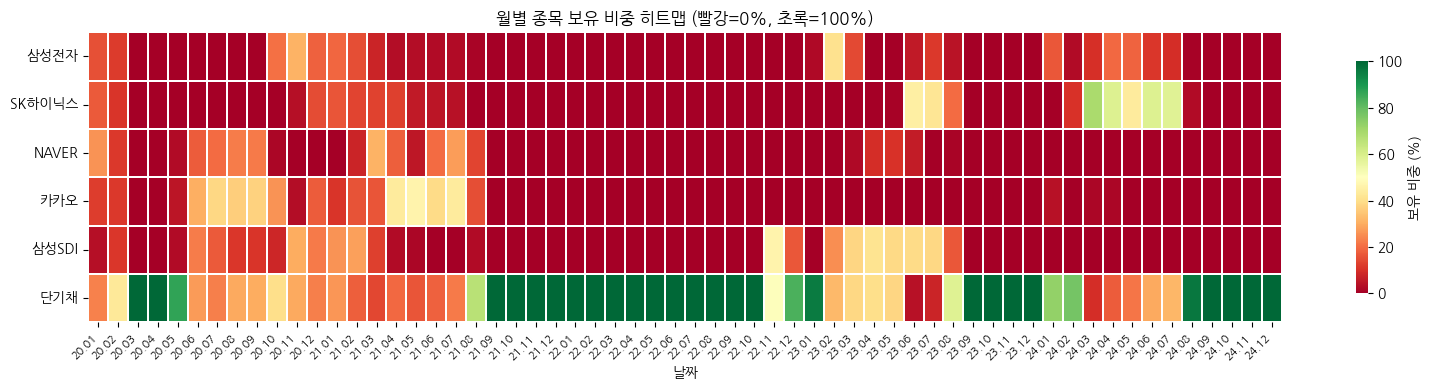


=== 종목별 평균 포지션 비중 ===
  삼성전자        : 5.3%  (최대 69.9%)
  SK하이닉스      : 8.8%  (최대 71.5%)
  NAVER       : 4.7%  (최대 70.1%)
  카카오         : 7.8%  (최대 59.1%)
  삼성SDI       : 8.7%  (최대 70.1%)
  단기채         : 62.1%  (최대 100.0%)


In [13]:
plot_weight_heatmap(pf_wf, names_all)

### 5-7. 종목별 수익 기여도

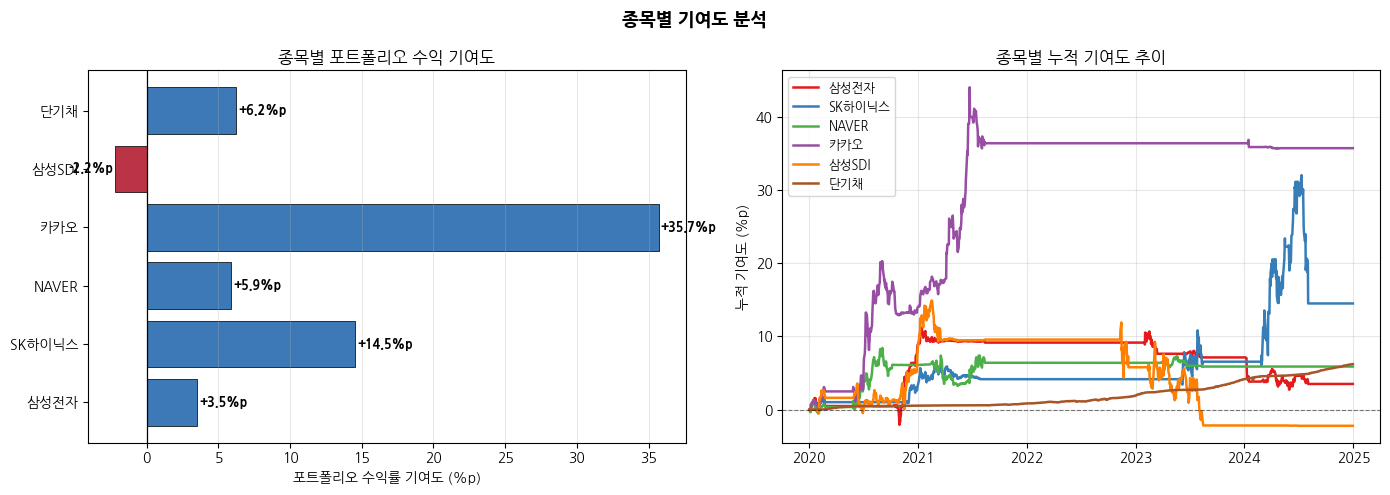

In [14]:
plot_contribution(pf_wf, wf_info['close_df_all'], names_all)

### 5-8. 분산투자 효과 (상관관계 + 변동성)

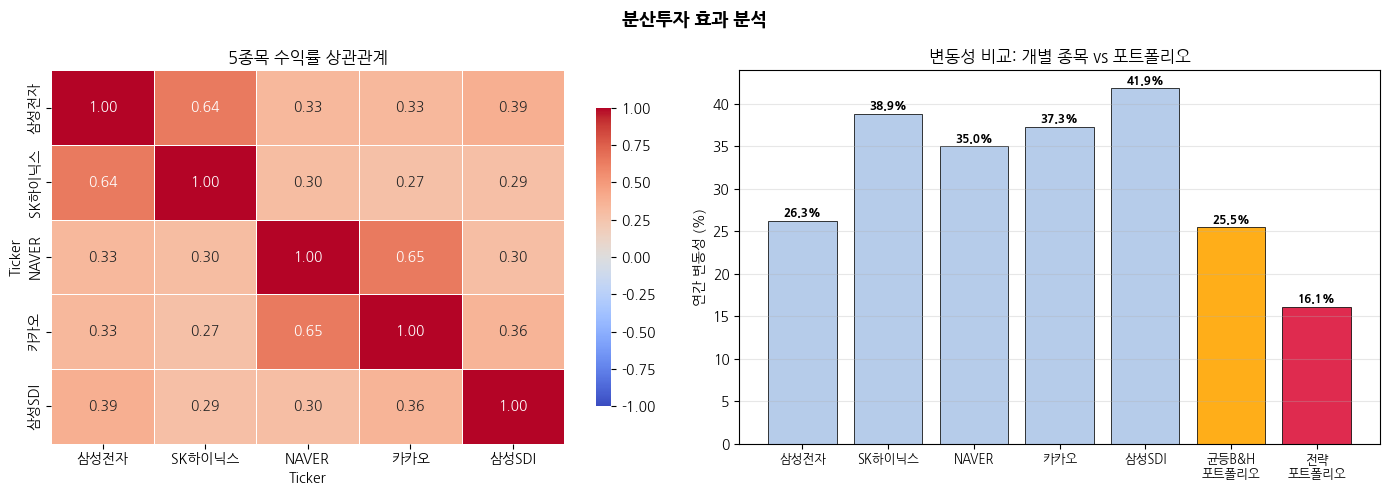

In [15]:
plot_diversification(pf_wf, close_df, names)

### 5-9. 주식 vs 단기채 연도별 기여도

    연도     주식 기여도      단기채 기여도     포트 총수익
--------------------------------------------
  2021    -51.11%       +72.55%     +24.17%
  2022     -1.59%        -1.67%      -3.58%
  2023     -6.22%        -1.49%      -8.47%
  2024    +11.70%        -8.31%      +0.54%


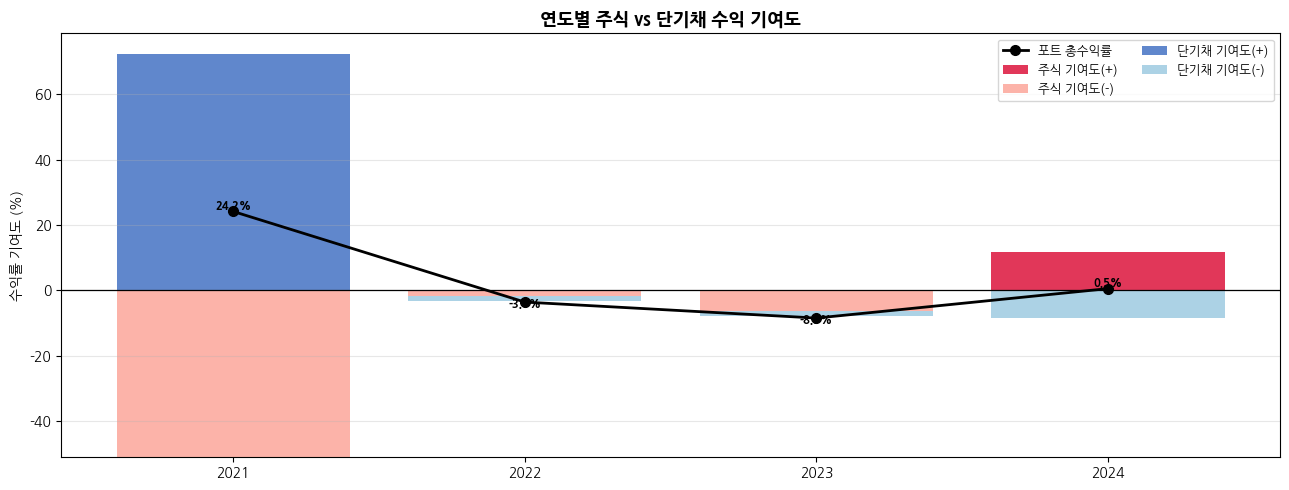

In [16]:
if CASH_ETF_NAME in names_all:
    plot_yearly_stock_etf(pf_wf, names_all, etf_name=CASH_ETF_NAME)
else:
    print('현금 ETF가 포함되지 않은 백테스트입니다. (CASH_ETF_TICKER=None 시 이 셀은 생략됩니다)')

---
## 6. 기간별 상세 분석

### 6-1. 연도별 수익률 비교 테이블

In [17]:
tbl_yearly = build_period_stats_table(
    pf_wf, pf_bh,
    benchmark_series=kospi,
    freq='Y',
    profile_name=PROFILE_NAME,
)
print(f'=== 연도별 수익률 비교 ===\n')
tbl_yearly

=== 연도별 수익률 비교 ===



,neutral(%),B&H(%),KOSPI(%),neutral-KOSPI(%p),neutral-B&H(%p)
2021,24.17,20.49,3.63,20.55,3.68
2022,-3.58,-39.69,-24.89,21.32,36.11
2023,-8.47,18.38,18.73,-27.20,-26.85
2024,0.54,-18.92,-9.63,10.18,19.47


### 6-2. 분기별 수익률 비교

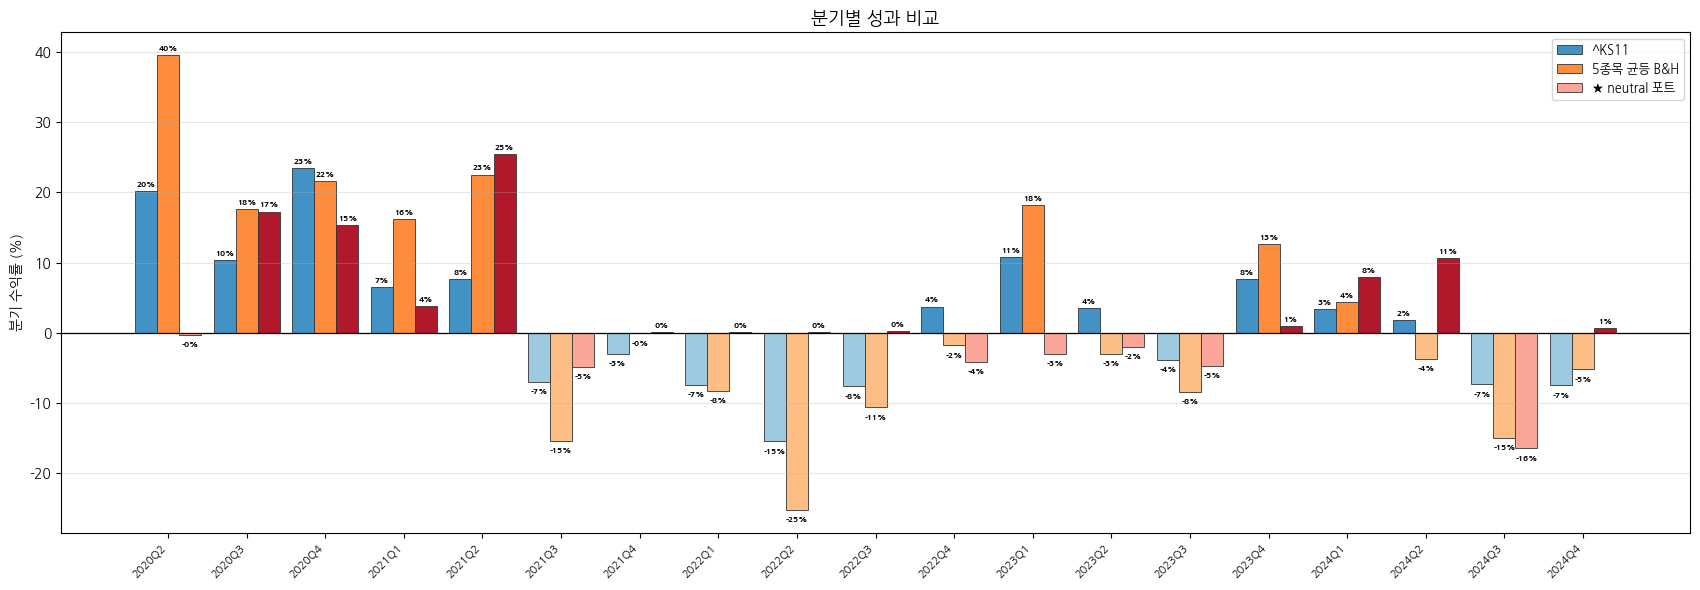

=== 분기별 수익률 비교 ===



,neutral(%),B&H(%),KOSPI(%),neutral-KOSPI(%p),neutral-B&H(%p)
2020Q2,-0.27,39.54,20.16,-20.42,-39.81
2020Q3,17.28,17.67,10.41,6.86,-0.39
2020Q4,15.29,21.65,23.44,-8.14,-6.36
2021Q1,3.83,16.21,6.54,-2.71,-12.38
2021Q2,25.41,22.54,7.68,17.73,2.87
2021Q3,-4.80,-15.34,-6.91,2.11,10.54
2021Q4,0.17,-0.06,-2.97,3.14,0.23
2022Q1,0.19,-8.28,-7.39,7.58,8.47
2022Q2,0.10,-25.17,-15.41,15.51,25.26
2022Q3,0.32,-10.57,-7.59,7.91,10.89


In [18]:
plot_quarterly_returns(
    pf_wf, pf_bh, n=len(names),
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

tbl_quarterly = build_period_stats_table(
    pf_wf, pf_bh,
    benchmark_series=kospi,
    freq='Q',
    profile_name=PROFILE_NAME,
)
print(f'=== 분기별 수익률 비교 ===\n')
tbl_quarterly

### 6-3. 월별 수익률 히트맵

> 빨강 = 손실, 초록 = 수익. 행 = 연도, 열 = 월, 마지막 열 = 연간 복리 수익률.

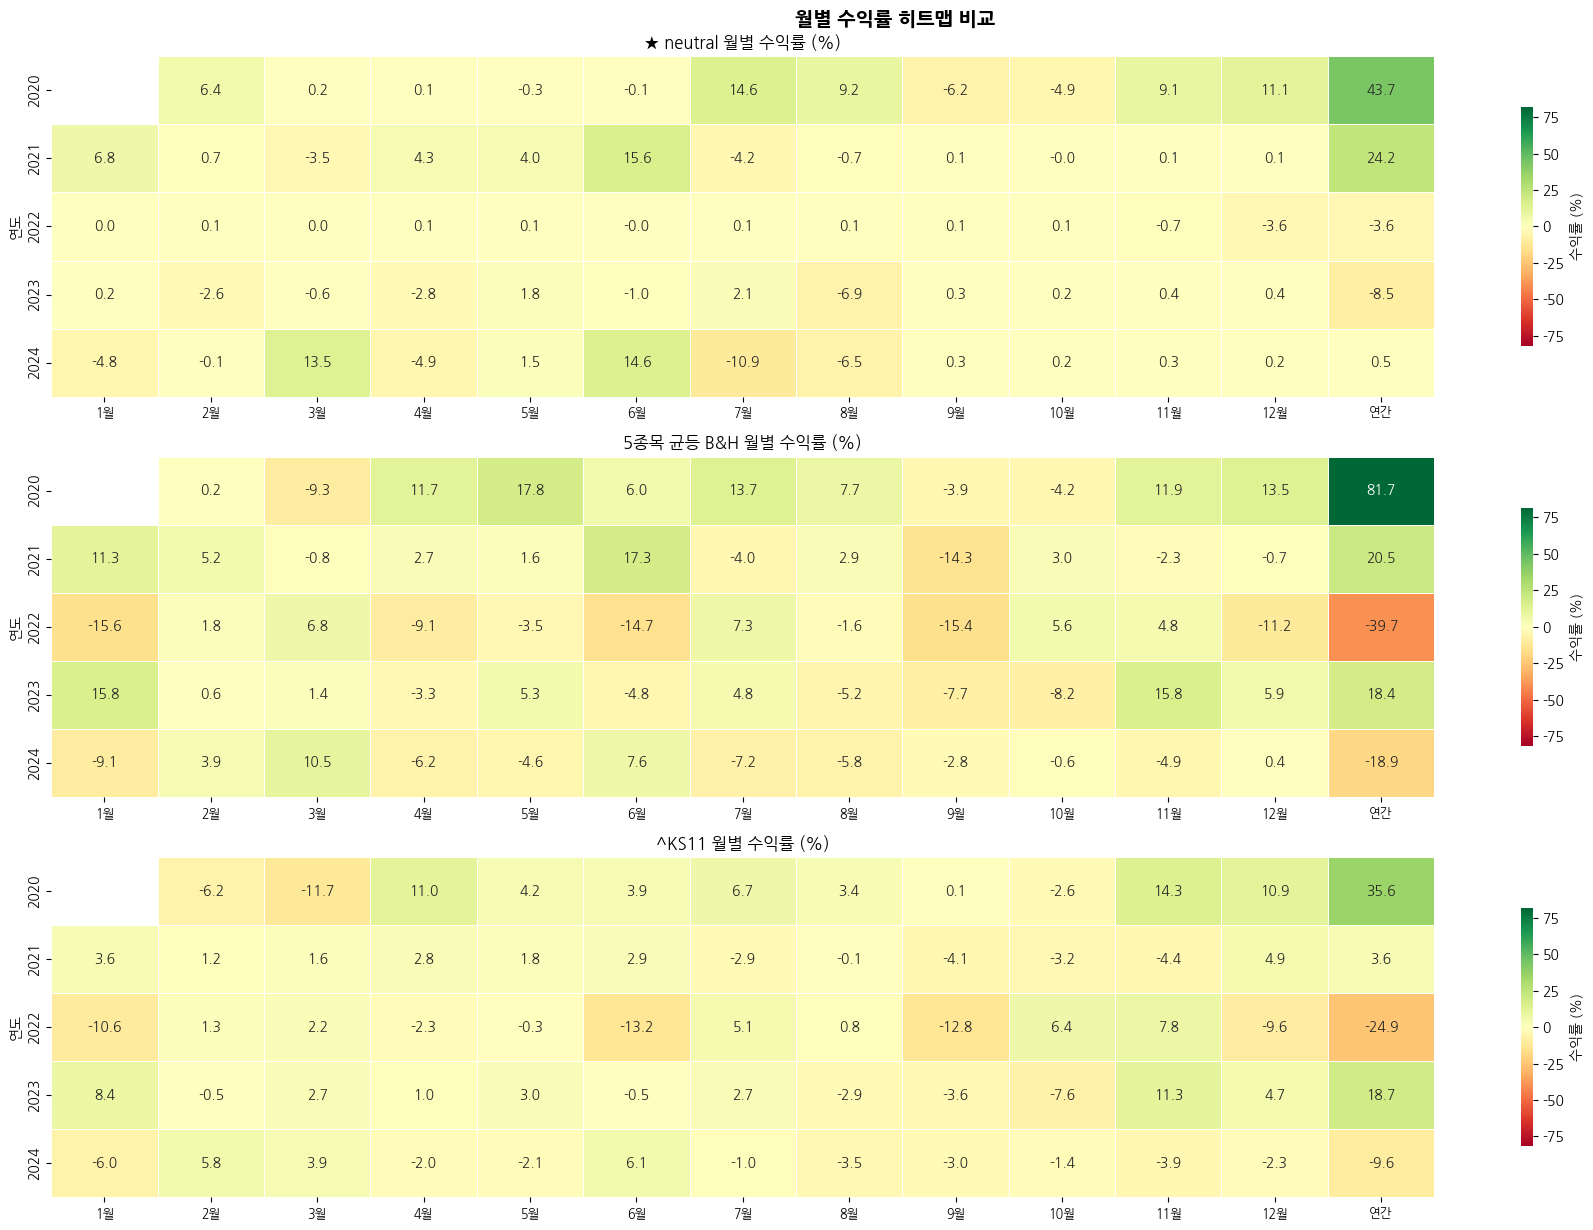

=== 월별 수익률 비교 ===



,neutral(%),B&H(%),KOSPI(%),neutral-KOSPI(%p),neutral-B&H(%p)
2020-02,6.38,0.25,-6.23,12.61,6.13
2020-03,0.17,-9.27,-11.69,11.87,9.44
2020-04,0.14,11.74,10.99,-10.85,-11.59
2020-05,-0.29,17.82,4.21,-4.50,-18.11
2020-06,-0.12,6.00,3.88,-4.00,-6.11
2020-07,14.59,13.69,6.69,7.90,0.89
2020-08,9.15,7.74,3.41,5.74,1.41
2020-09,-6.23,-3.94,0.07,-6.31,-2.29
2020-10,-4.89,-4.19,-2.61,-2.28,-0.71
2020-11,9.13,11.86,14.30,-5.17,-2.73


In [19]:
plot_monthly_heatmap(
    pf_wf, pf_bh, n=len(names),
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

tbl_monthly = build_period_stats_table(
    pf_wf, pf_bh,
    benchmark_series=kospi,
    freq='M',
    profile_name=PROFILE_NAME,
)
print(f'=== 월별 수익률 비교 ===\n')
tbl_monthly